In [4]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import yaml
import cv2
import matplotlib.pyplot as plt
import torch
import yaml

from ultralytics import YOLO

In [5]:
PROJECT_ROOT = Path.cwd().parent

METADATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "image_metadata.csv"
)

YOLO_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "yolo_plate_detection"
)

yaml_path = YOLO_DIR / "data.yaml"

images = pd.read_csv(METADATA_PATH)

images.head()

,split,track_id,frame_number,image_name,image_path,annotation_path,image_width,image_height,camera,vehicle_type,...,plate_brightness,plate_contrast,plate_blur_score,corners_valid,plate_box_valid,vehicle_box_valid,plate_inside_vehicle,character_count_matches,character_boxes_valid,annotation_valid
0,training,track0001,1,track0001[01].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,126.248095,38.710966,2236.944449,True,True,True,True,True,True,True
1,training,track0001,2,track0001[02].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,125.889396,37.965550,2143.694193,True,True,True,True,True,True,True
2,training,track0001,3,track0001[03].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,124.343629,36.829864,1958.690337,True,True,True,True,True,True,True
3,training,track0001,4,track0001[04].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,121.887827,37.349510,2167.056821,True,True,True,True,True,True,True
4,training,track0001,5,track0001[05].png,data/raw/ufpr_alpr/training/track0001/track000...,data/raw/ufpr_alpr/training/track0001/track000...,1920,1080,GoPro Hero4 Silver,car,...,121.563492,38.328790,1943.057892,True,True,True,True,True,True,True


In [6]:
# YOLO cannot directly train from a CSV. Instead, convert each image with images and labels where each label file contains
# class x_center y_center width height normalized between 0 and 1.
def convert_row_to_yolo(row):
    image_width = row["image_width"]
    image_height = row["image_height"]

    xmin = row["plate_xmin"]
    ymin = row["plate_ymin"]
    xmax = row["plate_xmax"]
    ymax = row["plate_ymax"]

    box_width_pixels = xmax - xmin
    box_height_pixels = ymax - ymin

    x_center_pixels = (xmin + xmax) / 2
    y_center_pixels = (ymin + ymax) / 2

    x_center = x_center_pixels / image_width
    y_center = y_center_pixels / image_height
    box_width = box_width_pixels / image_width
    box_height = box_height_pixels / image_height

    class_id = 0

    return (
        class_id,
        x_center,
        y_center,
        box_width,
        box_height,
    )

# Check
sample_row = images.iloc[0]

convert_row_to_yolo(sample_row)

class_id, x_center, y_center, box_width, box_height = (
    convert_row_to_yolo(sample_row)
)

print("Class:", class_id)
print("x center:", x_center)
print("y center:", y_center)
print("width:", box_width)
print("height:", box_height)

Class: 0
x center: 0.4942708333333333
y center: 0.49953703703703706
width: 0.03854166666666667
height: 0.025


In [7]:
# Copy image and create label files
split_map = {
    "training": "train",
    "validation": "val",
    "testing": "test",
}

for split in ["train", "val", "test"]:
    (YOLO_DIR / "images" / split).mkdir(
        parents=True,
        exist_ok=True,
    )

    (YOLO_DIR / "labels" / split).mkdir(
        parents=True,
        exist_ok=True,
    )

for index, row in images.iterrows():
    source_image_path = PROJECT_ROOT / row["image_path"]

    if not source_image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {source_image_path}"
        )

    yolo_split = split_map[row["split"]]

    destination_image_path = (
        YOLO_DIR
        / "images"
        / yolo_split
        / row["image_name"]
    )

    destination_label_path = (
        YOLO_DIR
        / "labels"
        / yolo_split
        / f"{Path(row['image_name']).stem}.txt"
    )

    shutil.copy2(
        source_image_path,
        destination_image_path,
    )

    (
        class_id,
        x_center,
        y_center,
        box_width,
        box_height,
    ) = convert_row_to_yolo(row)

    label_line = (
        f"{class_id} "
        f"{x_center:.8f} "
        f"{y_center:.8f} "
        f"{box_width:.8f} "
        f"{box_height:.8f}\n"
    )

    destination_label_path.write_text(
        label_line,
        encoding="utf-8",
    )

print("YOLO dataset created.")

YOLO dataset created.


In [8]:
# Validate image and label counts
for split in ["train", "val", "test"]:
    image_count = len(
        list((YOLO_DIR / "images" / split).glob("*.png"))
    )

    label_count = len(
        list((YOLO_DIR / "labels" / split).glob("*.txt"))
    )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

# Validate all label values
validation_errors = []

for split in ["train", "val", "test"]:
    label_paths = (
        YOLO_DIR
        / "labels"
        / split
    ).glob("*.txt")

    for label_path in label_paths:
        lines = label_path.read_text().strip().splitlines()

        if len(lines) != 1:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Expected 1 line, found {len(lines)}",
                }
            )
            continue

        values = lines[0].split()

        if len(values) != 5:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Expected 5 values, found {len(values)}",
                }
            )
            continue

        class_id = int(values[0])
        coordinates = np.array(
            [float(value) for value in values[1:]]
        )

        if class_id != 0:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Unexpected class ID: {class_id}",
                }
            )

        if not np.all(
            (coordinates >= 0)
            & (coordinates <= 1)
        ):
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": f"Coordinates outside range: {coordinates}",
                }
            )

        if coordinates[2] <= 0 or coordinates[3] <= 0:
            validation_errors.append(
                {
                    "label_path": str(label_path),
                    "error": "Width or height is not positive",
                }
            )

validation_errors = pd.DataFrame(validation_errors)

print("Validation errors:", len(validation_errors))

if not validation_errors.empty:
    display(validation_errors.head())

train: 1800 images, 1800 labels
val: 900 images, 900 labels
test: 1800 images, 1800 labels
Validation errors: 0


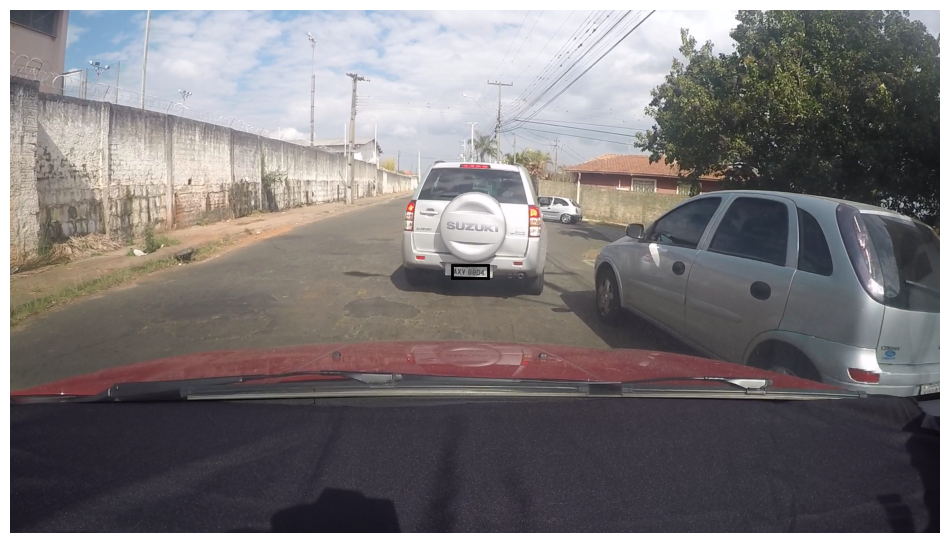

In [9]:
# Validate the bounding box
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def display_yolo_annotation(
    image_path,
    label_path,
):
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )

    image_height, image_width = image.shape[:2]

    label_values = (
        Path(label_path)
        .read_text()
        .strip()
        .split()
    )

    _, x_center, y_center, box_width, box_height = map(
        float,
        label_values,
    )

    box_width_pixels = box_width * image_width
    box_height_pixels = box_height * image_height

    xmin = (
        x_center * image_width
        - box_width_pixels / 2
    )

    ymin = (
        y_center * image_height
        - box_height_pixels / 2
    )

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.imshow(image)

    rectangle = Rectangle(
        (xmin, ymin),
        box_width_pixels,
        box_height_pixels,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(rectangle)
    ax.axis("off")

    plt.show()

sample_image = (
    YOLO_DIR
    / "images"
    / "train"
    / "track0001[01].png"
)

sample_label = (
    YOLO_DIR
    / "labels"
    / "train"
    / "track0001[01].txt"
)

display_yolo_annotation(
    sample_image,
    sample_label,
)

In [10]:
DEVICE = 0 if torch.cuda.is_available() else "cpu"

In [11]:
# Train model
MODEL_NAME = "yolo26n.pt"
RUN_NAME = "yolo26n_640_baseline"

EPOCHS = 50
IMAGE_SIZE = 640
BATCH_SIZE = 8
PATIENCE = 10

model = YOLO(MODEL_NAME)

data_yaml = {
    "path": str(YOLO_DIR.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "license_plate"
    }
}

yaml_path = YOLO_DIR / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f)

train_results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=DEVICE,
    workers=0,
    seed=42,
    deterministic=True,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, l

c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 219.325.0 MB/s, size: 2009.1 KB)
train: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\train.cache... 1800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1800/1800  0.0s
val: Fast image access  (ping: 0.10.0 ms, read: 280.926.5 MB/s, size: 2300.9 KB)
val: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\labels.jpg... 
Image sizes 640 train, 640 val
Using 0 dataloader workers


c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a


      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       1/50      1.25G      1.689      7.395   0.002705          7        640: 100% ━━━━━━━━━━━━ 225/225 1.8it/s 2:050.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.3it/s 44.9s0.8ss
                   all        900        900      0.766       0.86      0.894      0.489

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


...

      48/50      1.31G     0.5113     0.1625   0.000666          8        640: 100% ━━━━━━━━━━━━ 225/225 2.0it/s 1:500.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.5it/s 38.1s0.7ss
                   all        900        900       0.99      0.923       0.99      0.732

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

      49/50      1.31G     0.5037     0.1588  0.0006646          8        640: 100% ━━━━━━━━━━━━ 225/225 2.0it/s 1:510.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.5it/s 37.9s0.7ss
                   all        900        900      0.987      0.948      0.992      0.734

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

      50/50      1.31G     0.5033     0.1549  0.0006508          7        640: 100% ━━━━━━━━━━━━ 225/225 2.0it/s 1:500.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.5it/s 39.2s0.7ss
                   all        900        900      0.977      0.955      0.992      0.735

50 epochs completed in 2.447 hours.
Optimizer stripped from C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\weights\last.pt, 5.4MB
Optimizer stripped from C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\weights\best.pt, 5.4MB

Validating C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\weights\best.pt...
Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 1

In [ ]:
# Choose best checkpoint
RUN_DIR = (
    PROJECT_ROOT
    / "runs"
    / "detect"
    / RUN_NAME
)

BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"

print(BEST_WEIGHTS)
print(BEST_WEIGHTS.exists())

best_model = YOLO(str(BEST_WEIGHTS))

# Validate on best checkpoint
validation_results = best_model.val(
    data=str(yaml_path),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=f"{RUN_NAME}_validation",
)

validation_results.results_dict

c:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline\weights\best.pt
True
Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2029.2658.2 MB/s, size: 2429.3 KB)
val: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 2.7it/s 42.2s0.3s
                   all        900        900       0.96      0.971      0.992      0.738
Speed: 0.5ms preprocess, 8.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline_validation


{'metrics/precision(B)': 0.9604218957631541,
 'metrics/recall(B)': 0.970660122108747,
 'metrics/mAP50(B)': 0.9916418863637021,
 'metrics/mAP50-95(B)': 0.7378489094189178,
 'fitness': 0.7378489094189178}

In [13]:
# Validate on best held out test split
test_results = best_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=f"{RUN_NAME}_test",
)

test_results.results_dict

Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 249.837.6 MB/s, size: 2451.1 KB)
val: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\test... 1800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1800/1800 150.3it/s 12.0s0.1s
val: New cache created: C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 225/225 2.7it/s 1:240.4sss
                   all       1800       1800      0.982       0.92      0.978       0.75
Speed: 0.5ms preprocess, 7.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_640_baseline_test


{'metrics/precision(B)': 0.9822102008774429,
 'metrics/recall(B)': 0.9201998994832455,
 'metrics/mAP50(B)': 0.9779541982838243,
 'metrics/mAP50-95(B)': 0.7504989985454505,
 'fitness': 0.7504989985454505}

In [14]:
# Inspect training history
history = pd.read_csv(RUN_DIR / "results.csv")

history.columns = history.columns.str.strip()

history.head()

,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
0,1,169.843,1.68891,7.39461,0.00271,0.76627,0.86000,0.89427,0.48933,1.41862,4.33019,0.00290,0.000664,0.000664,0.000664
1,2,316.364,1.30952,3.04493,0.00167,0.88953,0.88577,0.95831,0.58711,1.32551,2.18440,0.00270,0.001304,0.001304,0.001304
2,3,459.717,1.23102,1.68930,0.00154,0.89941,0.90412,0.96689,0.62008,1.23380,1.36046,0.00248,0.001918,0.001918,0.001918
3,4,625.587,1.18488,1.02704,0.00146,0.90731,0.92111,0.97403,0.58648,1.36851,0.92969,0.00276,0.001881,0.001881,0.001881
4,5,882.173,1.08068,0.73626,0.00131,0.95866,0.94111,0.98723,0.66625,1.14408,0.63968,0.00230,0.001842,0.001842,0.001842


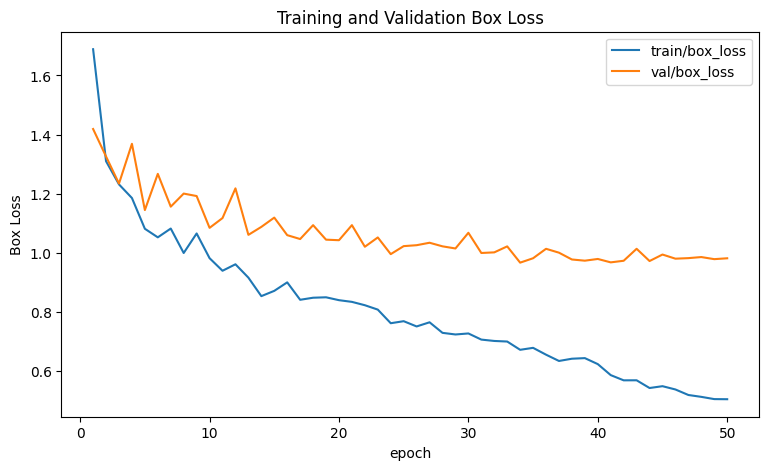

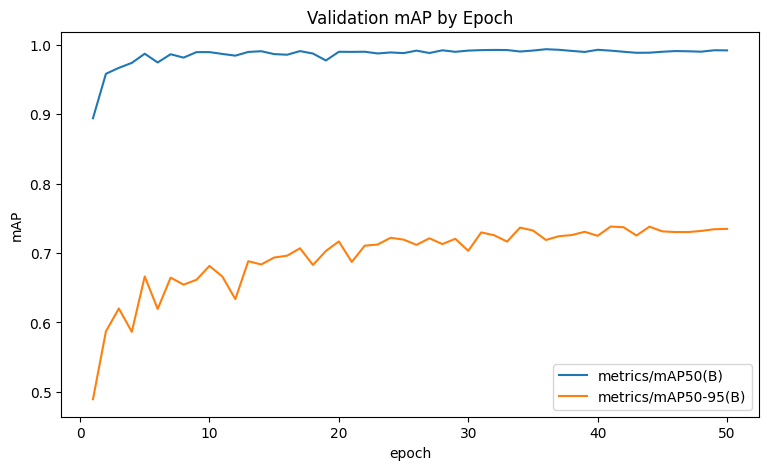

In [15]:
# Plot losses
history.plot(
    x="epoch",
    y=["train/box_loss", "val/box_loss"],
    figsize=(9, 5),
    title="Training and Validation Box Loss",
)

plt.ylabel("Box Loss")
plt.show()
# Training and Validation loss steadily decreases so model is learning
# However, overfitting as training keeps improving but validation slows down

# Plot validation
history.plot(
    x="epoch",
    y=["metrics/mAP50(B)", "metrics/mAP50-95(B)"],
    figsize=(9, 5),
    title="Validation mAP by Epoch",
)

plt.ylabel("mAP")
plt.show()
# mAP50 is high so finds plates very well (since only needs to match 50%) but mAP50-95 is lower so doesn't localize as well (since needs to match 95%)

## Hypothesis

The EDA showed that license plates occupy on average (`plate_area_ratio`) approximately **0.2%**. This means that the object detection model must find very small objects within high-resolution images.

The baseline YOLO model achieved nearly perfect **mAP@0.50** which shows that it can reliably detect license plates. However, the lower **mAP@0.50:0.95** means that the predicted bounding boxes are not tightly aligned with the actual boxes. In other words, the model successfully **detects** license plates but does not always **localize** them well.

One possible explanation is that the original **1920×1080** images are resized to **640×640** before being passed to the model. License plates are already very small relative to the full image so resizing further reduces the number of pixels representing each plate. Thus, a small localization error of a few pixels can have a large impact on the overall accuracy.

**Hypothesis:** Increasing the input image resolution from **640×640** to **960×960** will provide more pixels to represent each license plate, allowing the detector to predict more accurate bounding boxes. Therefore, we expect **mAP@0.50** to remain approximately the same, while **mAP@0.50:0.95** should improve due to better localization.

## Experiment

### Null hypothesis

Increasing the input resolution from 640×640 to 960×960 does not improve license-plate localization.

### Alternative hypothesis

Increasing the input resolution from 640×640 to 960×960 improves localization because each small license plate is represented by more input pixels.

In [17]:
RUN_NAME_960 = "yolo26n_960"

model_960 = YOLO("yolo26n.pt")

results_960 = model_960.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=960,           # only major experimental change
    batch=8,
    patience=10,
    device=DEVICE,
    workers=0,
    seed=42,
    deterministic=True,
    project=str(PROJECT_ROOT / "runs" / "detect"),
    name=RUN_NAME_960,
    exist_ok=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, l

c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

AMP: checks passed 
train: Fast image access  (ping: 0.20.0 ms, read: 1299.8316.4 MB/s, size: 2348.6 KB)
train: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\train.cache... 1800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1800/1800  0.0s
val: Fast image access  (ping: 0.10.0 ms, read: 1704.1557.6 MB/s, size: 2224.5 KB)
val: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_960\labels.jpg... 
Image sizes 960 train, 960 val
Using 0 dataloader workers
Loggi

c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

       1/50      3.23G      1.186      12.05   0.001602         17        960: 100% ━━━━━━━━━━━━ 225/225 1.5it/s 2:310.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.6it/s 36.3s0.7ss
                   all        900        900      0.756      0.809      0.878      0.634

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


...

      35/50      3.23G     0.5208     0.1864  0.0006011         16        960: 100% ━━━━━━━━━━━━ 225/225 1.9it/s 1:580.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.6it/s 34.9s0.6ss
                   all        900        900      0.995      0.975      0.994      0.777

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

      36/50      3.23G      0.486     0.1859   0.000548         15        960: 100% ━━━━━━━━━━━━ 225/225 1.9it/s 1:570.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.6it/s 35.0s0.6ss
                   all        900        900      0.979      0.983      0.994      0.778

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
      37/50      3.23G     0.3959     0.1152  0.0006917         12        960: 0% ──────────── 0/225  0.6s

c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:401: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:87.)
  sx = feats[0].new_ones(w, dtype=dtype).cumsum(0) - (1 - grid_cell_offset)  # shift x
c:\Users\mingj\Desktop\Plate-Recognition\venv\lib\site-packages\ultralytics\utils\tal.py:402: UserWarning: cumsum_cuda_kernel does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\a

      37/50      3.23G     0.5004      0.175  0.0005623         15        960: 100% ━━━━━━━━━━━━ 225/225 1.9it/s 1:570.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.6it/s 35.1s0.6ss
                   all        900        900      0.991      0.983      0.995      0.782
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 27, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

37 epochs completed in 1.580 hours.
Optimizer stripped from C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_960\weights\last.pt, 5.4MB
Optimizer stripped from C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_960\weights\best.pt, 5.4MB

Validating C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\yolo26n_960\weights\best.pt...
Ultralytics 8.4.114

In [18]:
# Choose best checkpoint
RUNS_DIR = PROJECT_ROOT / "runs" / "detect"

weights_640 = (
    RUNS_DIR
    / "yolo26n_640_baseline"
    / "weights"
    / "best.pt"
)

weights_960 = (
    RUNS_DIR
    / "yolo26n_960"
    / "weights"
    / "best.pt"
)

model_640 = YOLO(str(weights_640))
model_960 = YOLO(str(weights_960))

In [ ]:




# Validate on both splits
metrics_640 = model_640.val(
    data=str(yaml_path),
    split="val",
    imgsz=640,
    device=DEVICE,
    workers=0,
)

metrics_960 = model_960.val(
    data=str(yaml_path),
    split="val",
    imgsz=960,
    device=DEVICE,
    workers=0,
)

Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2000.3115.5 MB/s, size: 2412.4 KB)
val: Scanning C:\Users\mingj\Desktop\Plate-Recognition\data\processed\yolo_plate_detection\labels\val.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 1.7it/s 34.2s0.6ss
                   all        900        900       0.96       0.97      0.992      0.738
Speed: 0.3ms preprocess, 4.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\mingj\Desktop\Plate-Recognition\runs\detect\val
Ultralytics 8.4.114  Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs


In [20]:
# Comparison Table
comparison = pd.DataFrame(
    {
        "640": {
            "precision": metrics_640.box.mp,
            "recall": metrics_640.box.mr,
            "mAP50": metrics_640.box.map50,
            "mAP50-95": metrics_640.box.map,
        },
        "960": {
            "precision": metrics_960.box.mp,
            "recall": metrics_960.box.mr,
            "mAP50": metrics_960.box.map50,
            "mAP50-95": metrics_960.box.map,
        },
    }
)

comparison["difference"] = comparison["960"] - comparison["640"]
comparison

# Higher resolution improved localization but slightly decreased precision, recall, and finding plates (mAP50)

,640,960,difference
precision,0.960412,0.987787,0.027376
recall,0.970396,0.988571,0.018175
mAP50,0.991674,0.994465,0.002791
mAP50-95,0.737967,0.786350,0.048383
